In [1]:
import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import LogNorm
from tqdm import tqdm
import glob
import re

from datetime import datetime 
from tools import time_from_attr2, open_L2_CLOUD_GPC2

import warnings
warnings.filterwarnings("ignore")

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
results = earthaccess.search_data(
    short_name= "PACE_OCI_L2_CLOUD", 
    # temporal= ("2025-07-11", "2025-07-11"),
    temporal= ("2025-06-25T20:02:50", "2025-06-25T22:30:49"),
)

print(len(results))

11


In [4]:
# files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L2_CLOUD_v3_1")

In [11]:
path_OCI = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L2_CLOUD_v3_1/PACE_OCI.20250712T212833.L2.CLD.V3_1.nc"
ds_OCI = xr.open_dataset(path_OCI, group='geophysical_data')
nav_OCI = xr.open_dataset(path_OCI, group='navigation_data')      # 20250720T211449

In [12]:
data = ds_OCI['cer_21'].values
lon = nav_OCI['longitude']
lat = nav_OCI['latitude']

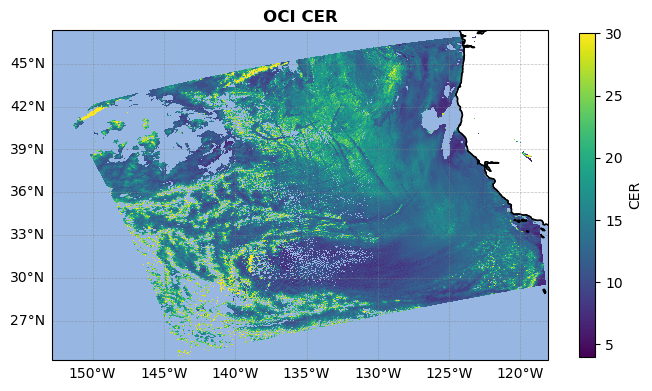

In [14]:
# Plotting
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
img = ax.pcolormesh(lon, lat, data, vmin=4, vmax=30, cmap='viridis', shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('OCI CER', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('CER')

plt.show()

In [15]:
def Nd_adiabatic_model(tau, re, Cw=0.0020, fad=0.7, k=0.8, Qe = 2.0):
    """
    tau: cloud optical thickness (τ) [unitless]
    re: cloud effective radius [µm]
    fad : adiabaticity of cloud [unitless]
    Cw:   lapse rate of water content [g/m^4]
    k:    disperson const rv^3 = k * re^3
    Qe:  extinction efficiency [unitless]

    """
    C = np.sqrt(5)/(2.0*np.pi*k)
    re_m = re*1e-6                      # change unit of re from um to m
    rho  = 1e6                          # density of water [g/m^3]
    CDNC = C * np.sqrt(fad*Cw*tau/Qe/rho/(re_m**5)) * 1e-6
    return CDNC

In [16]:
Nd = Nd_adiabatic_model(ds_OCI.cot_21, ds_OCI.cer_21)

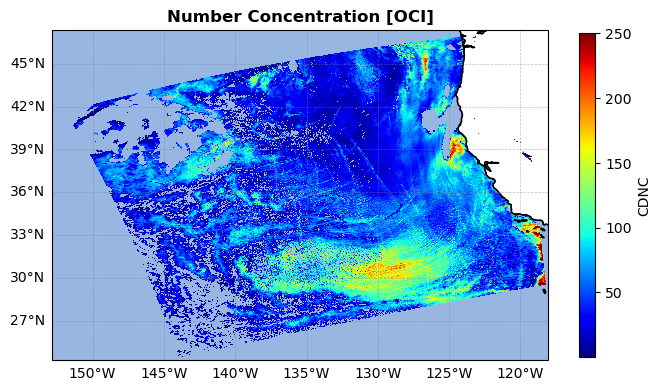

In [18]:
# Plotting
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon, lat, Nd.values, cmap='jet', vmax=250, shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('Number Concentration [OCI]', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7)
cbar.set_label('CDNC')

# plt.savefig("CDNC.png", dpi=500, bbox_inches="tight")
plt.show()

In [12]:
Nd.shape

(1709, 1272)

In [15]:
results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC", 
    # temporal=("2025-07-01", "2025-07-31"),
    temporal= ("2025-07-12T20:02:50", "2025-07-12T22:30:49"),
)
print(len(results))

13


In [18]:
# files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0")

In [19]:
path = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0/PACE_HARP2.20250712T212833.L2.CLOUD_GPC.V3_0.nc"
cloud_ds = xr.open_dataset(path, group='geophysical_data')
nav_ds = xr.open_dataset(path, group='geolocation_data')

In [20]:
data = cloud_ds['cloud_bow_droplet_effective_radius']
lon = nav_ds['longitude']
lat = nav_ds['latitude']

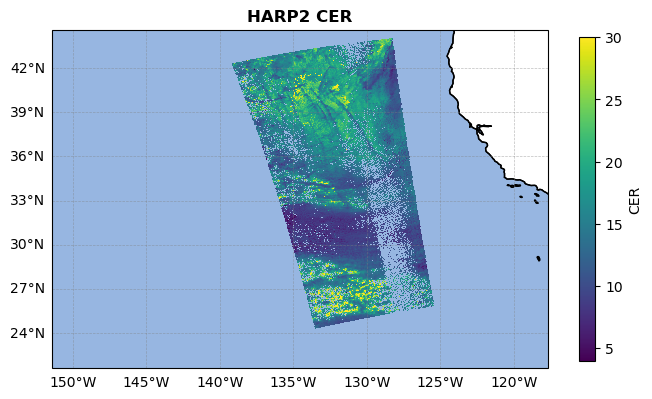

In [22]:
# Plotting
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
img = ax.pcolormesh(lon, lat, data, vmin=4, vmax=30, cmap='viridis', shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CER', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('CER')

plt.show()

In [9]:
# Find red dot pixel
lat_target = 29  
lon_target = -125 

# compute squared distance to target
dist = (lat - lat_target)**2 + (lon - lon_target)**2

# find nearest pixel
iy, ix = np.where(dist == np.min(dist))

print("Red dot pixel HARP2:", iy[0], ix[0])

Red dot pixel HARP2: 254 490


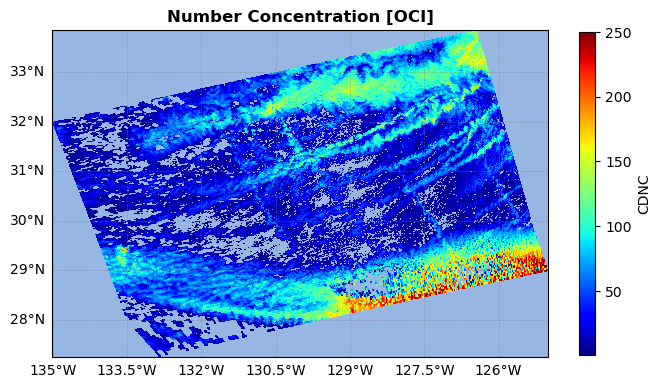

In [13]:
# Plotting
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon[254:662, 67:490], lat[254:662, 67:490], Nd.values[254:662, 67:490], cmap='jet', vmax=250, shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('Number Concentration [OCI]', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7)
cbar.set_label('CDNC')

# plt.savefig("CDNC.png", dpi=500, bbox_inches="tight")
plt.show()

### HARP-2

In [11]:
results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC", 
    temporal= ("2025-07-11", "2025-07-11"),
    # temporal= ("2025-07-06T19:20:50", "2025-07-06T19:25:49"),
    # count=1
)
print(len(results))

132


In [12]:
# files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0")

In [13]:
path_HARP2 = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0/PACE_HARP2.20250711T205323.L2.CLOUD_GPC.V3_0.nc"

In [14]:
ds = open_L2_CLOUD_GPC2(path_HARP2)

mask = (
    ~np.isnan(ds.cloud_bow_droplet_effective_radius) &
    ~np.isnan(ds.cloud_bow_droplet_effective_variance) &
    ~np.isnan(ds.cloud_bow_droplet_number_concentration_adiabatic)
)

cdnc = ds.cloud_bow_droplet_number_concentration_adiabatic.where(mask)

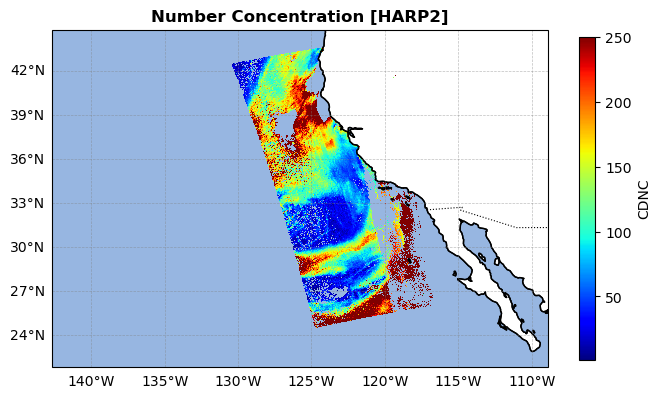

In [16]:
lat  = ds.latitude
lon  = ds.longitude

plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon, lat, cdnc, cmap='jet', vmax=250, shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('Number Concentration [HARP2]', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7)
cbar.set_label('CDNC')

# plt.savefig("CDNC.png", dpi=500, bbox_inches="tight")
plt.show()